# Workflow 12 -- SHAP analysis (tree-based hybrids, LightGBM lead)
## BRISC 2025 -- audited partition, 6 backbones x 4 tree classifiers

**Catarina Bota | UCP**

Feature-level explainability for the reliable tree-based hybrids. SHAP TreeExplainer is exact for gradient-boosted / forest models; the SVM and sklearn GradientBoosting were excluded because their explainers were numerically unstable (see the config cell). **LightGBM** is the lead model (best hybrid overall, W7 VGG16 + LightGBM = 98.67%).


## 1. Setup

In [8]:
import os, pickle, itertools, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

import shap
print('shap version:', shap.__version__)

shap version: 0.52.0


## 2. Configuration

In [9]:
PROJECT_DIR = '/mnt/c/Users/cbot/Desktop/BRISC pos graduação/brisc_gui'
OUT_ROOT    = f'{PROJECT_DIR}/w11_hybrid'
SHAP_DIR    = f'{OUT_ROOT}/shap'
os.makedirs(SHAP_DIR, exist_ok=True)

BACKBONES = [
    'W3_CNN_scratch',
    'W6_ResNet50_ImageNet',
    'W7_VGG16_ImageNet',
    'W8_EfficientNetB2_ImageNet',
    'W9_ConvNeXtTiny_ImageNet',
    'W10_RadImageNet_ResNet50',
]

# Only tree-based classifiers: SHAP TreeExplainer is exact and stable for these.
# Dropped: GradientBoosting (TreeExplainer returned all-zero for the multiclass
# sklearn GBM) and SVM/MLP (KernelExplainer diverged to ~1e10). SHAP over tree
# ensembles is the standard XAI choice in this literature (e.g. Nahiduzzaman 2025).
# LightGBM leads: it is the best hybrid overall (W7 98.67%) and has clean SHAP.
CLASSIFIERS = ['LightGBM', 'XGBoost', 'RandomForest', 'CatBoost']
LEAD_CLASSIFIER = 'LightGBM'

CLASSES = ['glioma', 'meningioma', 'no_tumor', 'pituitary']
print('backbones   :', BACKBONES)
print('classifiers :', CLASSIFIERS)
print('shap output :', SHAP_DIR)


backbones   : ['W3_CNN_scratch', 'W6_ResNet50_ImageNet', 'W7_VGG16_ImageNet', 'W8_EfficientNetB2_ImageNet', 'W9_ConvNeXtTiny_ImageNet', 'W10_RadImageNet_ResNet50']
classifiers : ['LightGBM', 'XGBoost', 'RandomForest', 'CatBoost']
shap output : /mnt/c/Users/cbot/Desktop/BRISC pos graduação/brisc_gui/w11_hybrid/shap


## 3. Helper: load features + trained classifier for a given (backbone, classifier) pair

W11 saved everything needed: the 128-d features (`features.npz`), the fitted `StandardScaler` (`scaler.pkl`) and each trained classifier (`classifiers/<name>.pkl`).

In [10]:
def load_pair(backbone, classifier):
    b = f'{OUT_ROOT}/{backbone}'
    d = np.load(f'{b}/features.npz')
    X_train, X_test = d['X_train'], d['X_test']
    y_train, y_test = d['y_train'], d['y_test']
    with open(f'{b}/scaler.pkl', 'rb') as f: scaler = pickle.load(f)
    Xtr = scaler.transform(X_train)
    Xte = scaler.transform(X_test)
    with open(f'{b}/classifiers/{classifier}.pkl', 'rb') as f: clf = pickle.load(f)
    return clf, Xtr, y_train, Xte, y_test


def compute_shap(backbone, classifier, verbose=True):
    # Exact TreeExplainer over standardized test features.
    # Returns (importance[128], per_sample[n,128], y_test); mean |SHAP| across classes.
    clf, Xtr, y_tr, Xte, y_te = load_pair(backbone, classifier)
    explainer = shap.TreeExplainer(clf)
    shap_vals = explainer.shap_values(Xte)
    if isinstance(shap_vals, list):
        sv = np.stack(shap_vals, axis=-1)          # (n, feats, classes)
    else:
        sv = np.asarray(shap_vals)
        if sv.ndim == 2:
            sv = sv[..., None]
    importance = np.mean(np.abs(sv), axis=(0, 2))   # (feats,)
    per_sample = np.mean(np.abs(sv), axis=2)         # (n, feats)
    if verbose:
        print(f'  {backbone:30s} {classifier:16s}  '
              f'|SHAP| max={importance.max():.4f}  top1=feat_{importance.argmax()}')
    return importance, per_sample, y_te


## 4. Compute SHAP for all (backbone x classifier) tree pairs

In [11]:
IMPORTANCE_CACHE = f'{SHAP_DIR}/importance_matrix.npz'

if os.path.exists(IMPORTANCE_CACHE):
    d = np.load(IMPORTANCE_CACHE, allow_pickle=True)
    imp_matrix = d['imp']
    print('Loaded cached importance matrix:', imp_matrix.shape)
else:
    imp_matrix = np.zeros((len(BACKBONES), len(CLASSIFIERS), 128), dtype=np.float32)
    for i, b in enumerate(BACKBONES):
        for j, c in enumerate(CLASSIFIERS):
            try:
                imp, _, _ = compute_shap(b, c, verbose=True)
                imp_matrix[i, j, :len(imp)] = imp
            except Exception as e:
                print(f'  [FAIL] {b} / {c}: {e}')
    np.savez_compressed(IMPORTANCE_CACHE, imp=imp_matrix,
                        backbones=BACKBONES, classifiers=CLASSIFIERS)
    print('Saved', IMPORTANCE_CACHE)

# Concentration = fraction of total |SHAP| carried by the top-10 features.
conc = np.zeros((len(BACKBONES), len(CLASSIFIERS)))
for i in range(len(BACKBONES)):
    for j in range(len(CLASSIFIERS)):
        v = imp_matrix[i, j]
        if v.sum() > 0:
            conc[i, j] = np.sort(v)[-10:].sum() / v.sum()
conc_df = pd.DataFrame(conc, index=BACKBONES, columns=CLASSIFIERS)
conc_df.to_csv(f'{SHAP_DIR}/top10_concentration.csv')
conc_df.round(3)

Loaded cached importance matrix: (6, 4, 128)


,LightGBM,XGBoost,RandomForest,CatBoost
W3_CNN_scratch,0.360,0.359,0.357,0.299
W6_ResNet50_ImageNet,0.510,0.555,0.386,0.374
W7_VGG16_ImageNet,0.591,0.612,0.394,0.403
W8_EfficientNetB2_ImageNet,0.373,0.379,0.319,0.268
W9_ConvNeXtTiny_ImageNet,0.437,0.495,0.371,0.310
W10_RadImageNet_ResNet50,0.476,0.533,0.410,0.512


## 5. Top-feature summary of the LightGBM lead across backbones

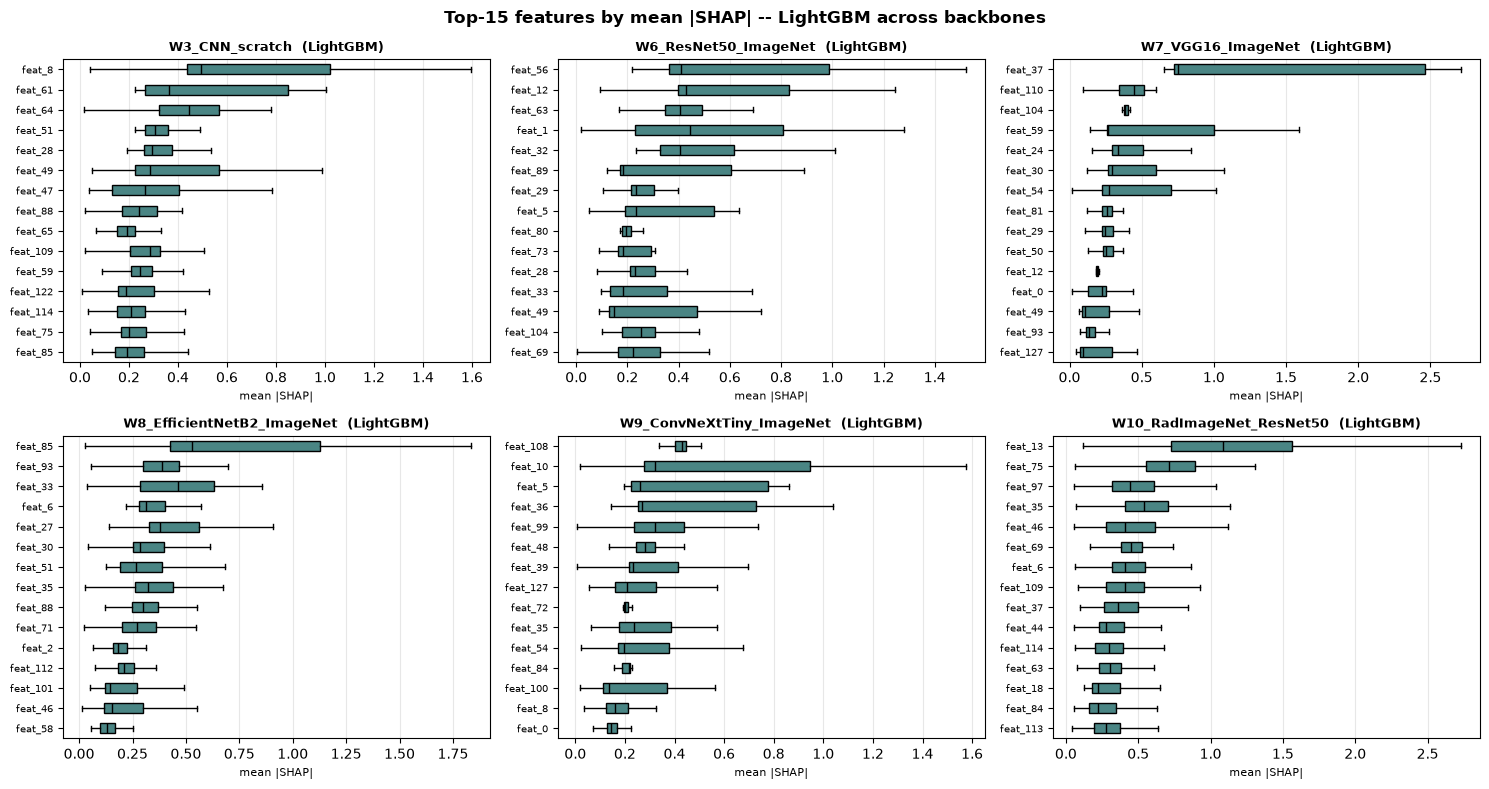

In [12]:
# Top-features summary of the LEAD classifier (LightGBM) across all 6 backbones.
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, b in enumerate(BACKBONES):
    ax = axes[i // 3, i % 3]
    imp, per_sample, y = compute_shap(b, LEAD_CLASSIFIER, verbose=False)
    top = np.argsort(imp)[-15:]
    data = per_sample[:, top]
    ax.boxplot([data[:, k] for k in range(data.shape[1])],
               vert=False, patch_artist=True,
               boxprops={'facecolor': '#4A8584'},
               medianprops={'color': 'black'}, showfliers=False)
    ax.set_yticks(range(1, len(top) + 1))
    ax.set_yticklabels([f'feat_{k}' for k in top], fontsize=7)
    ax.set_title(f'{b}  ({LEAD_CLASSIFIER})', fontsize=9, fontweight='bold')
    ax.set_xlabel('mean |SHAP|', fontsize=8)
    ax.grid(axis='x', alpha=0.3)
plt.suptitle(f'Top-15 features by mean |SHAP| -- {LEAD_CLASSIFIER} across backbones',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SHAP_DIR}/lightgbm_beeswarm.png', dpi=140, bbox_inches='tight')
plt.savefig(f'{SHAP_DIR}/lightgbm_beeswarm.pdf', bbox_inches='tight')
plt.show()


## 6. Spearman ρ between the 42 importance rankings

Computes rank-correlation between every pair of the 42 (backbone, classifier) importance vectors. Reveals whether classifiers cluster by **backbone** (same features regardless of classifier -- suggests the backbone dominates) or by **classifier family** (tree-based vs. kernel/net -- suggests classifier choice still matters).

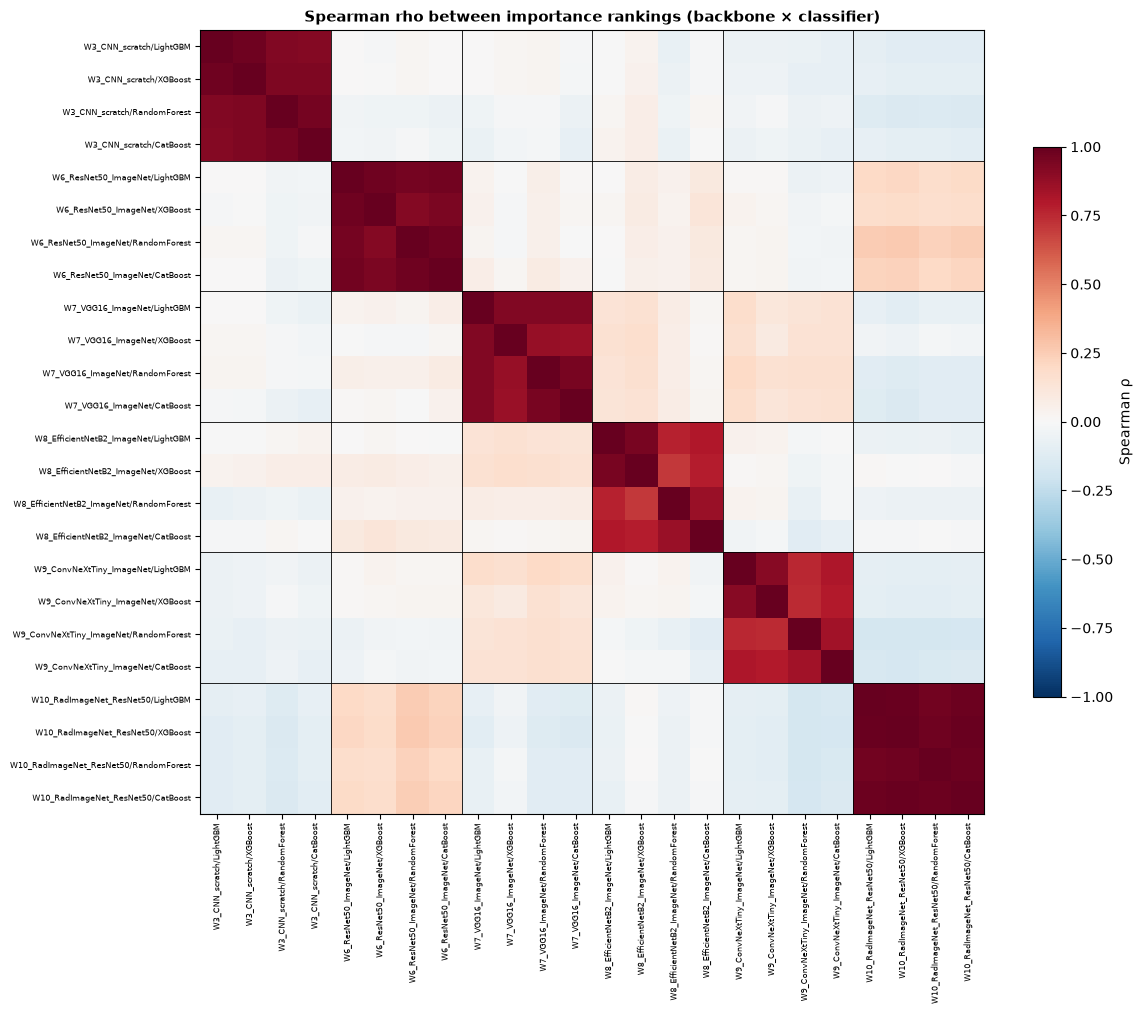

In [13]:
labels = [f'{b}\n{c}' for b in BACKBONES for c in CLASSIFIERS]
flat   = imp_matrix.reshape(len(BACKBONES) * len(CLASSIFIERS), -1)

n = flat.shape[0]
rho = np.eye(n)
for i in range(n):
    for j in range(i + 1, n):
        r, _ = spearmanr(flat[i], flat[j])
        rho[i, j] = rho[j, i] = r

rho_df = pd.DataFrame(rho,
                       index=[f'{b}/{c}' for b in BACKBONES for c in CLASSIFIERS],
                       columns=[f'{b}/{c}' for b in BACKBONES for c in CLASSIFIERS])
rho_df.to_csv(f'{SHAP_DIR}/spearman_rankings.csv')

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(rho, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels([f'{b}/{c}' for b in BACKBONES for c in CLASSIFIERS],
                   rotation=90, fontsize=6)
ax.set_yticklabels([f'{b}/{c}' for b in BACKBONES for c in CLASSIFIERS], fontsize=6)
# Draw block borders between backbones.
for k in range(1, len(BACKBONES)):
    ax.axhline(k * len(CLASSIFIERS) - 0.5, color='black', lw=0.6)
    ax.axvline(k * len(CLASSIFIERS) - 0.5, color='black', lw=0.6)
plt.colorbar(im, ax=ax, shrink=0.7, label='Spearman ρ')
ax.set_title('Spearman rho between importance rankings (backbone × classifier)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SHAP_DIR}/spearman_rankings.png', dpi=150, bbox_inches='tight')
plt.savefig(f'{SHAP_DIR}/spearman_rankings.pdf', bbox_inches='tight')
plt.show()

## 6. Within-backbone agreement (which dominates: backbone or classifier?)

**Only within-backbone comparisons are valid.** Each backbone has its own 128-d feature basis, so a feature index has no shared meaning across backbones; cross-backbone Spearman rho is therefore *not* interpretable and the off-diagonal blocks of the heatmap above should be ignored. Within a backbone (same feature space), a high mean pairwise rho across the four classifiers means the backbone representation dictates which features matter, largely independent of the classifier.

                  backbone  mean_rho_across_classifiers  min_rho  max_rho
  W10_RadImageNet_ResNet50                        0.979    0.964    0.988
      W6_ResNet50_ImageNet                        0.953    0.920    0.972
            W3_CNN_scratch                        0.939    0.915    0.976
         W7_VGG16_ImageNet                        0.912    0.862    0.950
W8_EfficientNetB2_ImageNet                        0.811    0.704    0.947
  W9_ConvNeXtTiny_ImageNet                        0.810    0.746    0.911

Overall mean within-backbone agreement: 0.901
=> High agreement: the BACKBONE representation dominates the feature
   importance; the classifier choice matters little once features are fixed.


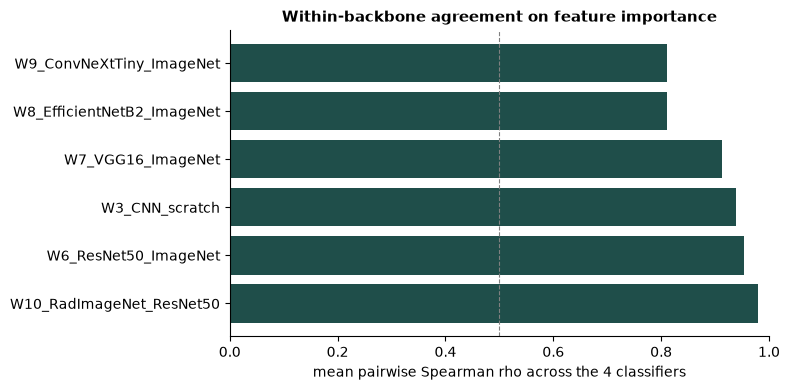

In [14]:
# Mean pairwise Spearman rho ACROSS the 4 classifiers, WITHIN each backbone.
nB, nC = len(BACKBONES), len(CLASSIFIERS)
def _idx(i, j): return i * nC + j

within_rows = []
for i, b in enumerate(BACKBONES):
    rs = [rho[_idx(i, j1), _idx(i, j2)]
          for j1 in range(nC) for j2 in range(j1 + 1, nC)]
    within_rows.append({'backbone': b, 'mean_rho_across_classifiers': round(float(np.mean(rs)), 3),
                        'min_rho': round(float(np.min(rs)), 3), 'max_rho': round(float(np.max(rs)), 3)})
within_df = pd.DataFrame(within_rows).sort_values('mean_rho_across_classifiers', ascending=False)
within_df.to_csv(f'{SHAP_DIR}/within_backbone_agreement.csv', index=False)
print(within_df.to_string(index=False))

overall = float(np.mean(within_df['mean_rho_across_classifiers']))
print(f'\nOverall mean within-backbone agreement: {overall:.3f}')
if overall >= 0.5:
    print('=> High agreement: the BACKBONE representation dominates the feature')
    print('   importance; the classifier choice matters little once features are fixed.')
else:
    print('=> Low/moderate agreement: the CLASSIFIER still shapes which features')
    print('   are used, even within a fixed backbone representation.')

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(within_df['backbone'], within_df['mean_rho_across_classifiers'], color='#1F4E4A')
ax.set_xlabel('mean pairwise Spearman rho across the 4 classifiers')
ax.set_xlim(0, 1); ax.axvline(0.5, ls='--', color='grey', lw=0.8)
ax.set_title('Within-backbone agreement on feature importance', fontsize=11, fontweight='bold')
for s in ['top', 'right']: ax.spines[s].set_visible(False)
plt.tight_layout()
plt.savefig(f'{SHAP_DIR}/within_backbone_agreement.png', dpi=150, bbox_inches='tight')
plt.savefig(f'{SHAP_DIR}/within_backbone_agreement.pdf', bbox_inches='tight')
plt.show()


## 7. Concentration heatmap (top-10 features / total)

If a classifier can be reduced to 10 out of 128 features without losing much |SHAP| mass, the underlying representation is *low-effective-dimensional* -- a deployment/interpretability win. If concentration is close to 10/128 ≈ 0.08, the signal is spread evenly (every feature matters, no easy reduction).

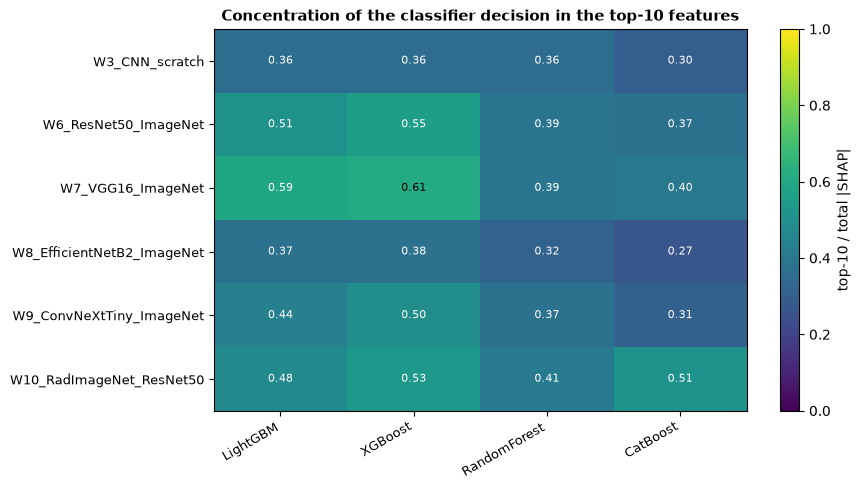

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(conc, cmap='viridis', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(CLASSIFIERS))); ax.set_yticks(range(len(BACKBONES)))
ax.set_xticklabels(CLASSIFIERS, rotation=30, ha='right', fontsize=9)
ax.set_yticklabels(BACKBONES, fontsize=9)
for i in range(len(BACKBONES)):
    for j in range(len(CLASSIFIERS)):
        ax.text(j, i, f'{conc[i, j]:.2f}', ha='center', va='center',
                color='white' if conc[i, j] < 0.6 else 'black', fontsize=8)
plt.colorbar(im, ax=ax, label='top-10 / total |SHAP|')
ax.set_title('Concentration of the classifier decision in the top-10 features',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SHAP_DIR}/concentration.png', dpi=150, bbox_inches='tight')
plt.savefig(f'{SHAP_DIR}/concentration.pdf', bbox_inches='tight')
plt.show()

## 8. Interpretation checklist (for the paper)

Look at the three figures side by side and answer these:

1. **Grad-CAM (notebook 11)** -- are the ImageNet backbones focused on the tumour, and is RadImageNet diffuse? If yes, visual corroboration of the W10 accuracy gap.

2. **SHAP beeswarm (Section 5)** -- is the top-feature identity **the same across backbones** (features 0-127 are not aligned across backbones -- each backbone has its own 128-d basis, so this comparison is not literal, but the *shape* of the distribution is)?

3. **Spearman ρ (Section 6)** -- what dominates the clustering?
   - If blocks along the diagonal (same backbone) are red: **the backbone dominates** (classifier choice matters little once features are fixed).
   - If off-diagonal blocks (same classifier, different backbone) show high ρ: **the classifier family** imposes a decision pattern independently of the backbone -- much rarer.

4. **Concentration (Section 7)** -- does the RadImageNet row show a *different* concentration than the ImageNet rows? If W10 is highly concentrated (few features carry the signal) it suggests **the RadImageNet features contain a useful sub-signal that a hybrid classifier finds** -- reframes the W10 story from "bad pretraining" to "pretraining that softmax cannot use, but a classifier can".

5. **Delta vs softmax (Notebook 11 Section 4)** -- for which backbones does the hybrid beat the softmax head, and by how much? Big Δ on W10 confirms point 4; small Δ across the board confirms diminishing returns of the hybrid pattern on already-strong backbones.